<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/29July.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df = pd.read_csv('/content/drive/MyDrive/Classified Data.txt')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1000 non-null   int64  
 1   WTT           1000 non-null   float64
 2   PTI           1000 non-null   float64
 3   EQW           1000 non-null   float64
 4   SBI           1000 non-null   float64
 5   LQE           1000 non-null   float64
 6   QWG           1000 non-null   float64
 7   FDJ           1000 non-null   float64
 8   PJF           1000 non-null   float64
 9   HQE           1000 non-null   float64
 10  NXJ           1000 non-null   float64
 11  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 93.9 KB


In [25]:
df.describe()

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,288.819436,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.000000,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,249.750000,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,499.500000,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,749.250000,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,999.000000,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

Fit the features data only to this estimator(leaving the target class  column ) and transform

In [27]:
scaler.fit(df.drop('TARGET CLASS',axis=1))
scaled_features = scaler.transform(df.drop('TARGET CLASS', axis=1))

In [28]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,Unnamed: 0,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-1.730320,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.726856,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-1.723391,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,-1.719927,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,-1.716463,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


Train , test , Split

In [29]:
from sklearn.model_selection import train_test_split
X = df_feat
y = df['TARGET CLASS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [30]:
print(X_train.shape)
print(X_test.shape)

(700, 11)
(300, 11)


In [31]:
print(y_train.shape)
print(y_test.shape)

(700,)
(300,)


In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=4)

In [33]:
pred = knn.predict(X_test)

##Evaluation of classification quality

In [34]:
from sklearn.metrics import classification_report , confusion_matrix
conf_mat = confusion_matrix(y_test,pred)
print(conf_mat)

[[155   4]
 [ 18 123]]


In [35]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       159
           1       0.97      0.87      0.92       141

    accuracy                           0.93       300
   macro avg       0.93      0.92      0.93       300
weighted avg       0.93      0.93      0.93       300



In [36]:
print("Misclassification error rate: " , round(np.mean(pred!=y_test) , 3))

Misclassification error rate:  0.073


In [37]:
error_rate = []
for i in range(1,60):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  pred_i = knn.predict(X_test)
  error_rate.append(np.mean(pred_i!=y_test))


Text(0, 0.5, 'Error (misclassification) Rate ')

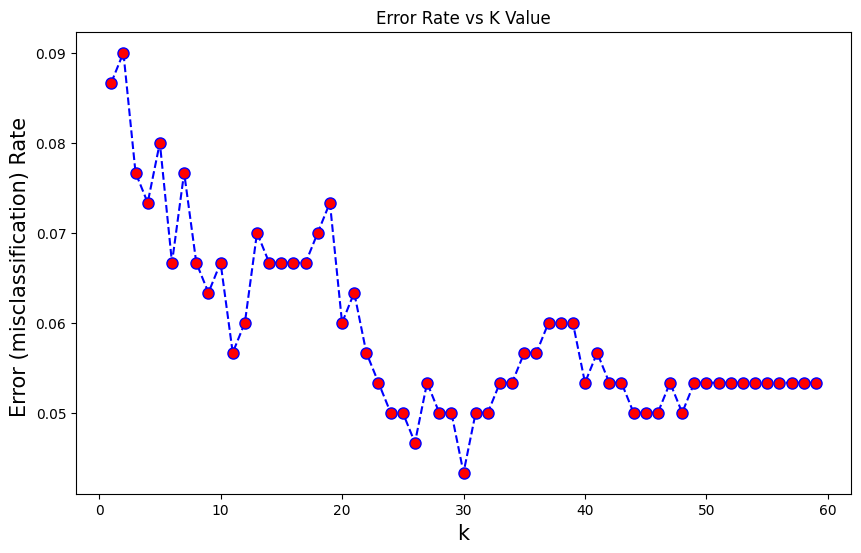

In [38]:
plt.figure(figsize=(10,6))
plt.plot(range(1,60),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=8)
plt.title('Error Rate vs K Value')
plt.xlabel('k' , fontsize=15)
plt.ylabel('Error (misclassification) Rate ' , fontsize=15)

In [46]:
df = pd.read_csv('/content/drive/MyDrive/Social_Network_Ads - Social_Network_Ads - Social_Network_Ads - Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [47]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [51]:
scaler.fit(df.drop('Purchased',axis=1))
scaled_features = scaler.transform(df.drop('Purchased', axis=1))

In [52]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [54]:
from sklearn.model_selection import train_test_split
X = df_feat
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [55]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(120,)

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=4)

In [58]:
pred = knn.predict(X_test)

In [60]:
from sklearn.metrics import confusion_matrix , classification_report
conf_mat = confusion_matrix(y_test , pred)
conf_mat

array([[74,  6],
       [ 3, 37]])

In [61]:
print("Misclassification error rate: " , round(np.mean(pred!=y_test) , 3))

Misclassification error rate:  0.075


In [62]:
error_rate = []
for i in range(1,10):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  pred_i = knn.predict(X_test)
  error_rate.append(np.mean(pred_i!=y_test))


Text(0, 0.5, 'Error (misclassification) Rate ')

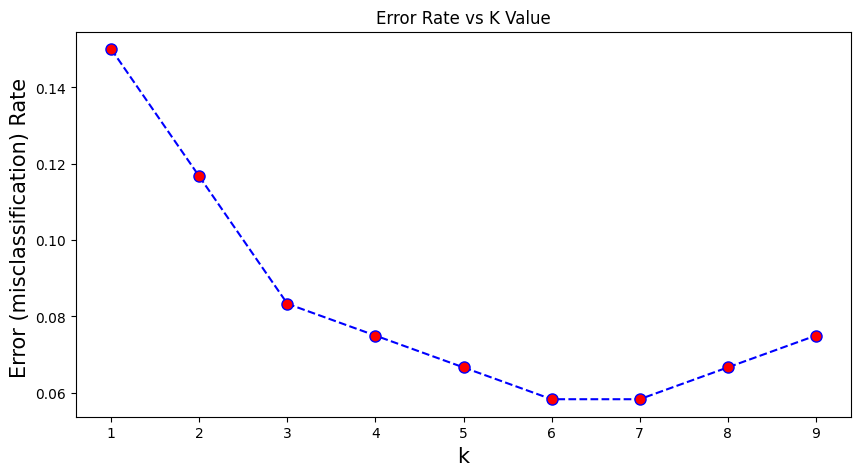

In [63]:
plt.figure(figsize=(10,5))
plt.plot(range(1,10),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=8)
plt.title('Error Rate vs K Value')
plt.xlabel('k' , fontsize=15)
plt.ylabel('Error (misclassification) Rate ' , fontsize=15)

In [67]:
from sklearn.datasets import make_classification
X , y = make_classification(n_features=6, n_classes=3, n_samples=800 , n_informative=2, random_state=1,n_clusters_per_class=1)


In [68]:
X

array([[ 1.34076287, -1.21573796, -0.06929943,  0.84542643, -0.76549575,
        -1.31889683],
       [ 0.49869261, -0.23490061, -0.43071779,  0.75949359, -0.42755223,
        -1.10296955],
       [-0.83870221,  1.11953787, -0.62576716, -0.92699247,  0.24284264,
         0.75537433],
       ...,
       [ 1.44604798, -1.04922808, -0.56296398, -0.15364732, -0.99780991,
         0.81598915],
       [ 0.41410711, -0.65405841,  0.49773464, -2.45291986, -0.05332349,
        -0.04538256],
       [ 0.92293213, -0.79973894, -0.11690007, -1.33230529, -0.55134594,
        -0.37302019]])

In [69]:
y

array([1, 0, 2, 0, 1, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0, 0, 0, 1, 1, 2, 0, 0,
       0, 1, 1, 2, 1, 0, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2, 0, 0, 0,
       2, 1, 2, 1, 1, 0, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0, 1, 2, 1, 2, 0, 2,
       2, 2, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 0, 1, 2, 1,
       2, 0, 0, 1, 0, 1, 1, 0, 0, 2, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 2, 0, 1, 2, 1, 2, 0, 2, 1, 0, 0, 1, 2, 2, 0, 2,
       1, 0, 2, 1, 1, 1, 0, 0, 2, 2, 1, 2, 2, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 2, 0, 1, 0, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 2, 1, 0, 2, 2, 0,
       2, 2, 1, 0, 1, 1, 1, 0, 2, 0, 2, 0, 1, 1, 2, 2, 2, 2, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 2, 2, 1, 2, 0, 1, 0, 2, 2, 0, 1, 2, 2, 0, 1,
       0, 1, 1, 2, 2, 0, 1, 1, 0, 2, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 2, 2,
       1, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 1, 0, 0, 1, 2, 0, 2, 1, 1, 1, 1,
       1, 2, 1, 0, 2, 1, 1, 1, 2, 0, 0, 2, 2, 0, 0, 1, 1, 2, 0, 0, 1, 0,
       0, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 1, 2, 2, 1,

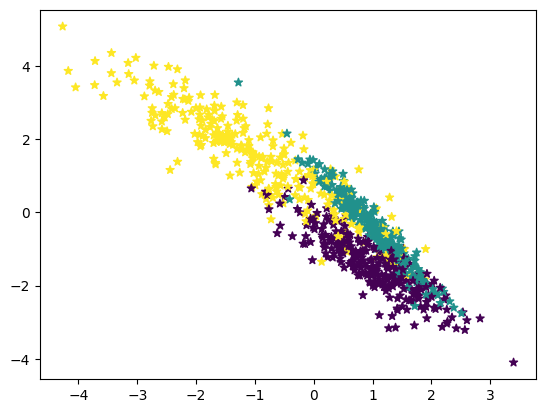

In [70]:
import matplotlib.pyplot as plt
plt.scatter(X[: , 0] , X[:,1], c=y , marker="*")

In [71]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=125)

In [72]:
X_train.shape
X_test.shape

(240, 6)

In [73]:
from sklearn.naive_bayes import GaussianNB
# build a Gaussian Classifier
model = GaussianNB()
# model training
model.fit(X_train,y_train)
# predict output
predicted = model.predict([X_test[6]])

print("Actual value: " , y_test[6])
print("Predicted value: " , predicted[0])

Actual value:  0
Predicted value:  0


In [76]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_pred , y_test)
f1 = f1_score(y_pred , y_test ,average="weighted")
print("Accuracy: ",accuracy)
print("F1 score: " ,f1)
print(confusion_matrix(y_test ,y_pred))

Accuracy:  0.8583333333333333
F1 score:  0.8584984959105599
[[71  5  2]
 [10 79  2]
 [ 3 12 56]]


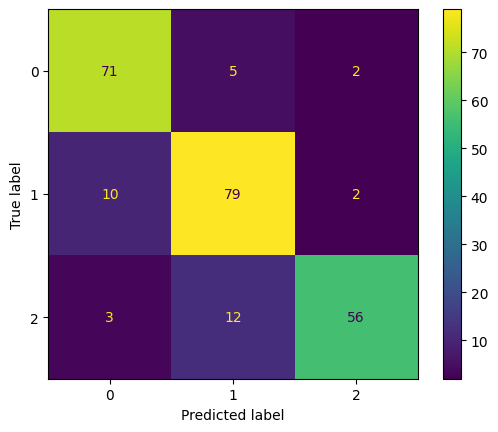

In [77]:
labels = [0,1,2]
cm = confusion_matrix(y_test , y_pred , labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=labels)
disp.plot()
plt.show()